<a href="https://colab.research.google.com/github/finn-mcduffee8/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Finn McDuffee and Carter Moorefield

## Part A: Restate Your Baseline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")

        plt.tight_layout()
        plt.show()

    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer: We have 3 classes

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

X3_scaler = StandardScaler()
X3_train_scaled = X3_scaler.fit_transform(X3_train)
X3_test_scaled = X3_scaler.transform(X3_test)

In [ ]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(3, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers: We used a softmax activation function.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


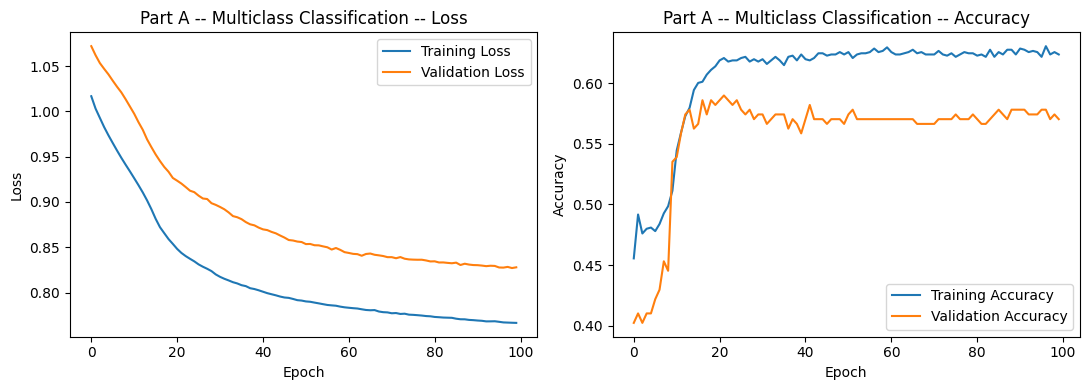

In [ ]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(
    history_multi,
    "Part A -- Multiclass Classification",
    show_accuracy=True
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part A -- Test Accuracy: 0.609


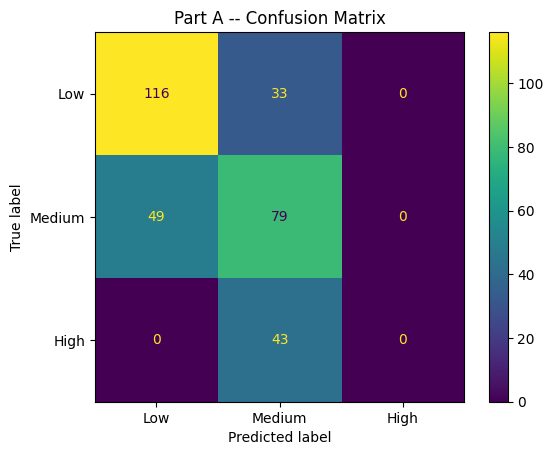

In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part A -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(
    cm3,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part A -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer:

In [ ]:
# The original part 3 model had an accuracy of 63.7%. Altough the trainign and validation loss were close in early training,
# a gap formed around 15-20 epochs.
# Since the model continued to improve on the training data while the validation perfomance stopped improving,
#This showed mild overfitting.

##Part B: Hyperparameter Tuning


In [ ]:
!pip install keras-tuner --quiet
import keras_tuner as kt

In [ ]:
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(hp.Int("hidden1", min_value=16, max_value=128, step=16),activation="relu",input_shape=(X3_train_scaled.shape[1],)),

        tf.keras.layers.Dense(hp.Int("hidden2", min_value=8, max_value=64, step=8),activation="relu"),

        tf.keras.layers.Dense(n_classes,activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                values=[0.001, 0.01, 0.1]
            )
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hidden layer 1:", best_hp.get("hidden1"))
print("Best hidden layer 2:", best_hp.get("hidden2"))
print("Best learning rate:", best_hp.get("learning_rate"))

Best hidden layer 1: 48
Best hidden layer 2: 32
Best learning rate: 0.01


In [ ]:
final_model = tuner.hypermodel.build(best_hp)

history_final = final_model.fit(
    X3_train_scaled,
    y3_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

print(f"Tuned Model Test Accuracy: {test_accuracy:.3f}")

Tuned Model Test Accuracy: 0.703


In [ ]:
# The original lab 1 model had an accuracy of 63.7%
# The final model after hyperparamater tuning had an accuracy of 66%
# Therefore the result improved by 2.3%.

## Part C: Addressing Overfitting

In [ ]:
# Dropout
model_regularized = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(
            96, activation="relu", input_shape=(X3_train_scaled.shape[1],)
        ),
        tf.keras.layers.Dropout(0.3),  # Dropout layer 1
        tf.keras.layers.Dense(48, activation="relu"),
        tf.keras.layers.Dropout(0.2),  # Dropout layer 2
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ]
)

model_regularized.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history_regularized = model_regularized.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

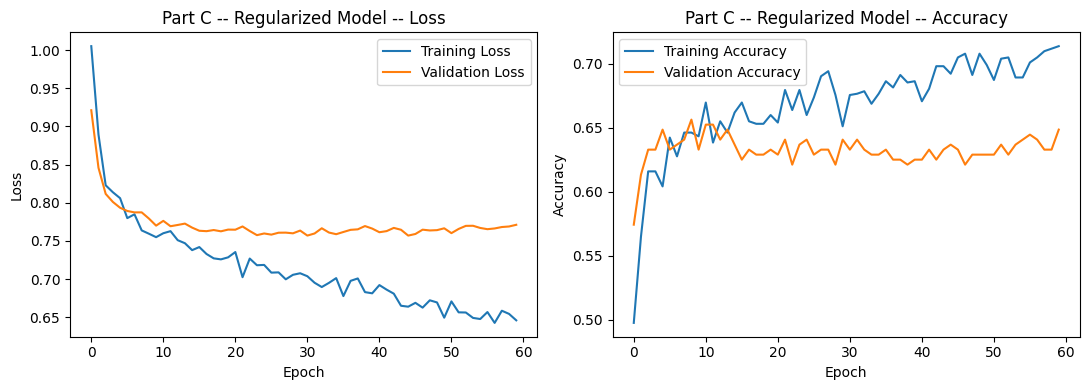

In [ ]:
plot_history(
    history_regularized, "Part C -- Regularized Model", show_accuracy=True
)

In [ ]:
reg_probs = model_regularized.predict(X3_test_scaled)
reg_preds = np.argmax(reg_probs, axis=1)

acc_reg = accuracy_score(y3_test, reg_preds)
print(f"Part C -- Final Test Accuracy: {acc_reg:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part C -- Final Test Accuracy: 0.675


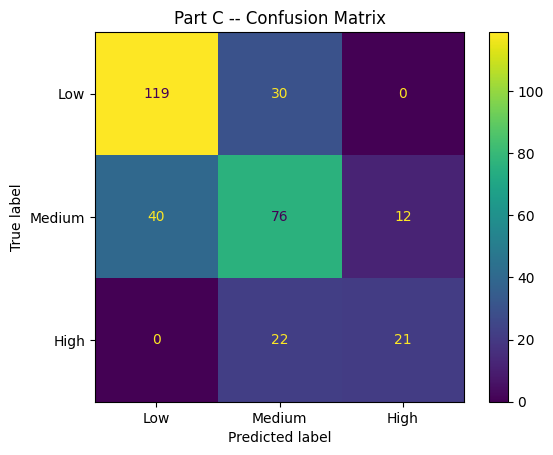

In [ ]:
cm_reg = confusion_matrix(y3_test, reg_preds)
ConfusionMatrixDisplay(
    cm_reg, display_labels=["Low", "Medium", "High"]
).plot()
plt.title("Part C -- Confusion Matrix")
plt.show()

## Part D: Reflection

In [ ]:
# We keep the test set untouched until the very end to make sure that
# our model will have an unbiased test aganist real-world data.
# If the test set had been used to pick the hyperparameters, information from
# test set would've leaked into the tuning process and make our result look
# more favorable than it otherwise would've been.
# Dropout and Early stopping did meaningfully reduce overfitting, as shown by
# the validation curve aligned to the training loss curve before diverging.
# With unlimited time, we could've added better weighing systems to our model.